# Loan Approval Dataset — Preprocessing Pipeline
**Dataset:** `loan_approval_raw.csv` | **Shape:** (5080, 19) | **Target:** `LoanApproved`

## 📦 Imports

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split


## Step 1 — Load & Initial Inspection

In [29]:
df = pd.read_csv("loan_approval_raw.csv")

print(f"Shape   : {df.shape}")
print(f"Columns : {df.columns.tolist()}")
print("\nFirst 5 rows:")
display(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nNull Counts:")
print(df.isnull().sum())
print(f"\nDuplicate Rows: {df.duplicated().sum()}")


Shape   : (5080, 19)
Columns : ['CustomerID', 'Age', 'Gender', 'MaritalStatus', 'Dependents', 'Education', 'JobType', 'City', 'PropertyArea', 'Experience', 'Income', 'LoanAmount', 'LoanTenure', 'CreditScore', 'ExistingLoans', 'MonthlyEMI', 'LoanToIncome', 'RandomReference', 'LoanApproved']

First 5 rows:


,CustomerID,Age,Gender,MaritalStatus,Dependents,Education,JobType,City,PropertyArea,Experience,Income,LoanAmount,LoanTenure,CreditScore,ExistingLoans,MonthlyEMI,LoanToIncome,RandomReference,LoanApproved
0,CUST02300,37,Female,Married,4,Master,Salaried,Mumbai,Urban,19,30942.137914,29868.308638,48,558.0,3,622.26,0.9653,32658,1
1,CUST03772,35,Male,Married,4,Master,Business,Delhi,Rural,17,18254.087781,462740.480652,24,610.0,5,19280.85,25.3500,75159,1
2,CUST00034,45,Male,Divorced,3,PhD,Salaried,Mumbai,Urban,22,54143.931702,67853.183160,24,694.0,3,2827.22,1.2532,95398,1
3,CUST01245,60,Male,Divorced,3,High School,Salaried,Mumbai,Semi-Urban,12,20077.392441,114870.717826,12,770.0,1,9572.56,5.7214,88786,1
4,CUST03051,61,Female,Married,4,Bachelor,Business,Delhi,Urban,4,24672.165216,82662.038063,120,456.0,2,688.85,3.3504,89796,0



Data Types:
CustomerID          object
Age                 object
Gender              object
MaritalStatus       object
Dependents           int64
Education           object
JobType             object
City                object
PropertyArea        object
Experience           int64
Income             float64
LoanAmount         float64
LoanTenure           int64
CreditScore        float64
ExistingLoans        int64
MonthlyEMI         float64
LoanToIncome       float64
RandomReference      int64
LoanApproved         int64
dtype: object

Null Counts:
CustomerID           0
Age                  8
Gender               0
MaritalStatus        0
Dependents           0
Education          142
JobType              0
City                 0
PropertyArea        61
Experience           0
Income             221
LoanAmount          93
LoanTenure           0
CreditScore        181
ExistingLoans        0
MonthlyEMI           0
LoanToIncome         0
RandomReference      0
LoanApproved         0
dtype: in

## Step 2 — Remove Duplicates & Irrelevant Columns

In [30]:
print(f"Shape before : {df.shape}")
print(f"Duplicate rows: {df.duplicated().sum()}")

df = df.drop_duplicates()

df = df.drop(columns=["CustomerID", "RandomReference"], errors="ignore")

print(f"Shape after  : {df.shape}")
print("Remaining columns:", df.columns.tolist())


Shape before : (5080, 19)
Duplicate rows: 80
Shape after  : (5000, 17)
Remaining columns: ['Age', 'Gender', 'MaritalStatus', 'Dependents', 'Education', 'JobType', 'City', 'PropertyArea', 'Experience', 'Income', 'LoanAmount', 'LoanTenure', 'CreditScore', 'ExistingLoans', 'MonthlyEMI', 'LoanToIncome', 'LoanApproved']


## Step 3 — Fix Incorrect Data Types

In [31]:
print("Data Types Before:")
print(df.dtypes)

df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
print("\nConverted 'Age' → numeric")

print("\nData Types After:")
print(df.dtypes)


Data Types Before:
Age               object
Gender            object
MaritalStatus     object
Dependents         int64
Education         object
JobType           object
City              object
PropertyArea      object
Experience         int64
Income           float64
LoanAmount       float64
LoanTenure         int64
CreditScore      float64
ExistingLoans      int64
MonthlyEMI       float64
LoanToIncome     float64
LoanApproved       int64
dtype: object

Converted 'Age' → numeric

Data Types After:
Age              float64
Gender            object
MaritalStatus     object
Dependents         int64
Education         object
JobType           object
City              object
PropertyArea      object
Experience         int64
Income           float64
LoanAmount       float64
LoanTenure         int64
CreditScore      float64
ExistingLoans      int64
MonthlyEMI       float64
LoanToIncome     float64
LoanApproved       int64
dtype: object


## Step 4 — Handle Missing Values

In [32]:
print("Null counts BEFORE:")
print(df.isnull().sum()[df.isnull().sum() > 0])


numeric_fill = ["Age", "Income", "LoanAmount", "CreditScore"]
for col in numeric_fill:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"  {col}: filled with median = {median_val:.2f}")

cat_fill = ["Education", "PropertyArea"]
for col in cat_fill:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f"  {col}: filled with mode = '{mode_val}'")

print("\nNull counts AFTER:")
print(df.isnull().sum())
print("\nAll nulls resolved:", df.isnull().sum().sum() == 0)


Null counts BEFORE:
Age              55
Education       140
PropertyArea     60
Income          219
LoanAmount       90
CreditScore     180
dtype: int64
  Age: filled with median = 44.00
  Income: filled with median = 42022.74
  LoanAmount: filled with median = 124262.00
  CreditScore: filled with median = 649.00
  Education: filled with mode = 'Bachelor'
  PropertyArea: filled with mode = 'Urban'

Null counts AFTER:
Age              0
Gender           0
MaritalStatus    0
Dependents       0
Education        0
JobType          0
City             0
PropertyArea     0
Experience       0
Income           0
LoanAmount       0
LoanTenure       0
CreditScore      0
ExistingLoans    0
MonthlyEMI       0
LoanToIncome     0
LoanApproved     0
dtype: int64

All nulls resolved: True


## Step 5 — Handle Outliers (IQR Clipping)

Income: clipped to [-33114.01, 127340.00]
LoanAmount: clipped to [-171588.38, 455514.97]
MonthlyEMI: clipped to [-5750.86, 12829.55]
LoanToIncome: clipped to [-5.40, 12.58]


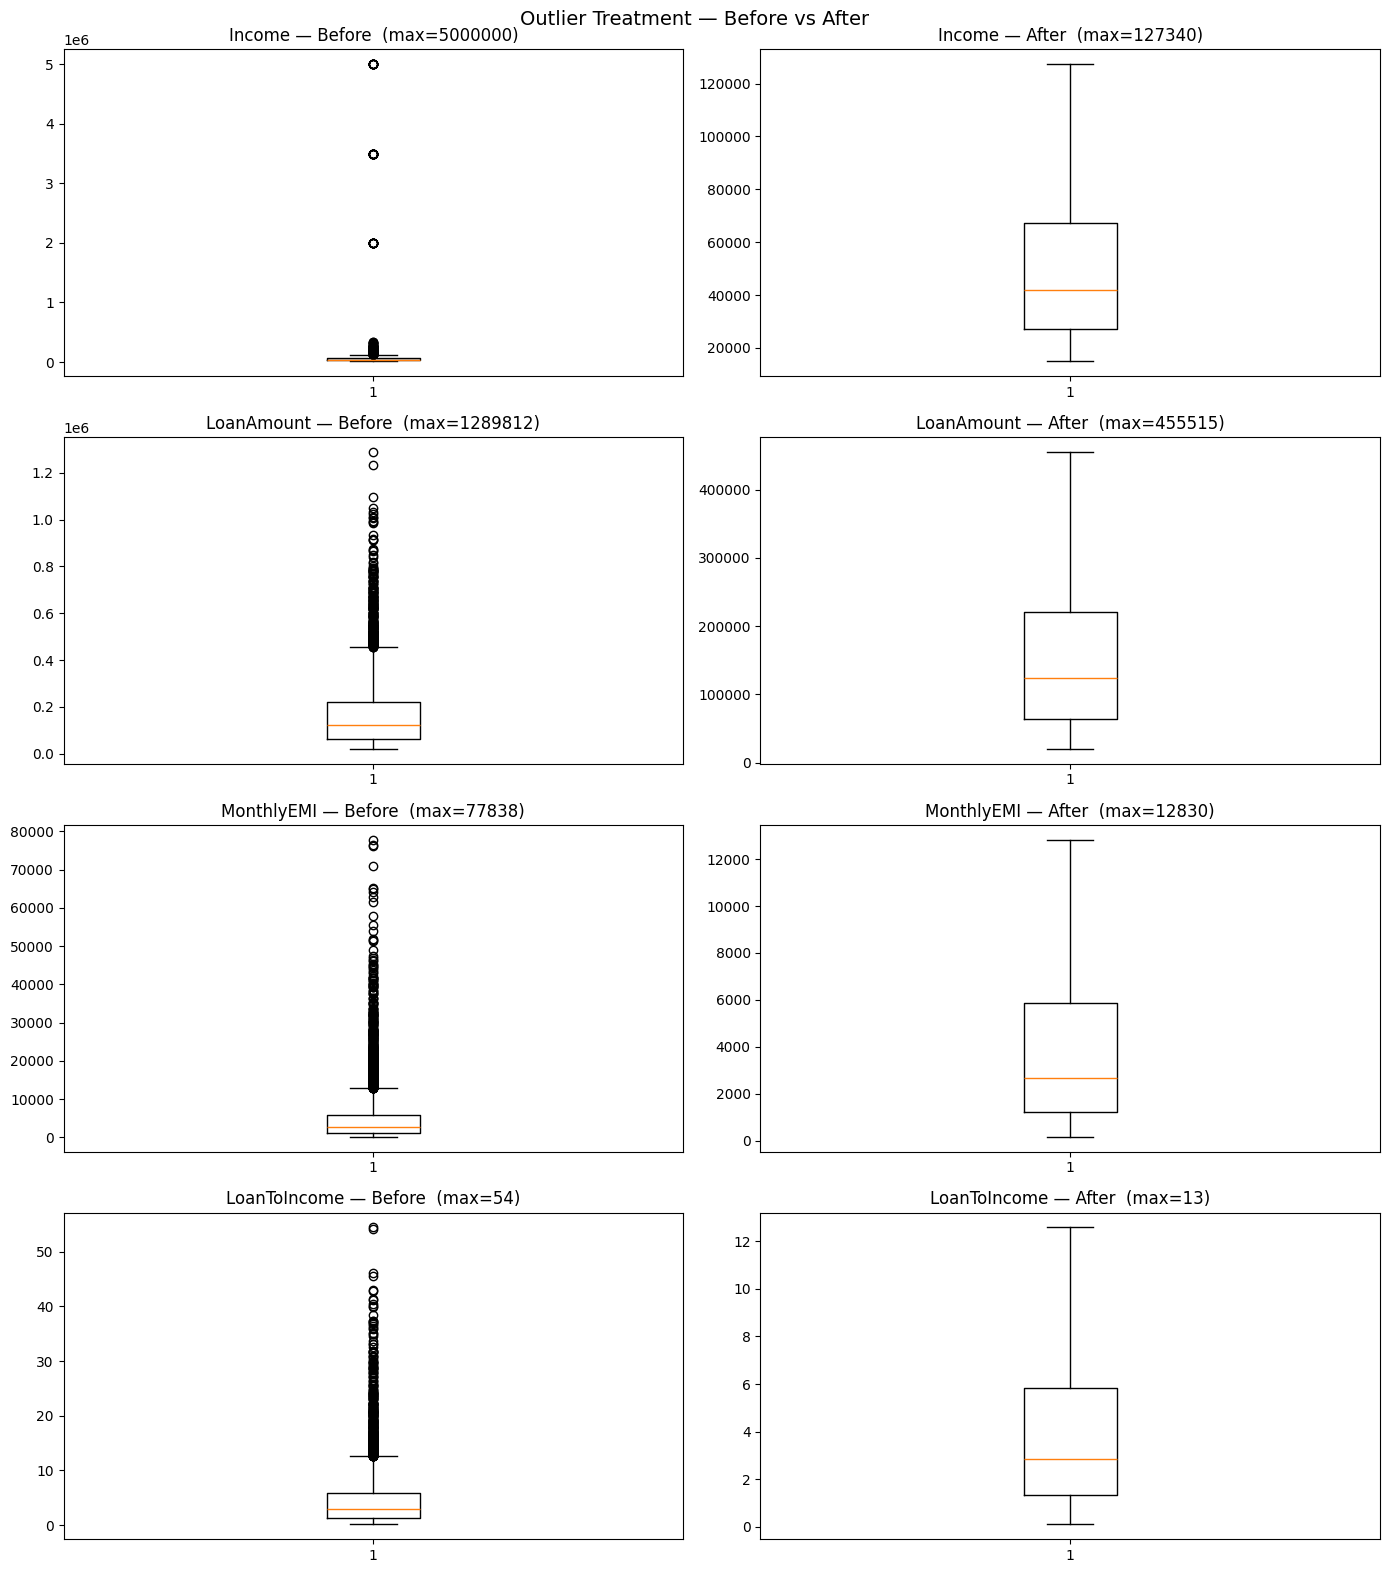

In [33]:
outlier_cols = ["Income", "LoanAmount", "MonthlyEMI", "LoanToIncome"]

fig, axes = plt.subplots(len(outlier_cols), 2, figsize=(14, 4 * len(outlier_cols)))
fig.suptitle("Outlier Treatment — Before vs After", fontsize=14)

for i, col in enumerate(outlier_cols):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Plot BEFORE
    axes[i, 0].boxplot(df[col].dropna())
    axes[i, 0].set_title(f"{col} — Before  (max={df[col].max():.0f})")

    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f"{col}: clipped to [{lower:.2f}, {upper:.2f}]")

    # Plot AFTER
    axes[i, 1].boxplot(df[col].dropna())
    axes[i, 1].set_title(f"{col} — After  (max={df[col].max():.0f})")

plt.tight_layout()
plt.show()


## Step 6 — Encode Categorical Variables

In [34]:
# Binary → Label Encoding
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])
print("Gender → Label Encoded (Female=0, Male=1)")

# Ordinal → Manual Ordinal Encoding
education_order = {"High School": 0, "Bachelor": 1, "Master": 2, "PhD": 3}
df["Education"] = df["Education"].map(education_order)
print(f"Education → Ordinal Encoded: {education_order}")

# Nominal → One-Hot Encoding
ohe_cols = ["MaritalStatus", "JobType", "City", "PropertyArea"]
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)

# Convert bool → int
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

print(f"\nOne-Hot Encoded: {ohe_cols}")
print(f"Shape after encoding: {df.shape}")
display(df.head())


Gender → Label Encoded (Female=0, Male=1)
Education → Ordinal Encoded: {'High School': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}

One-Hot Encoded: ['MaritalStatus', 'JobType', 'City', 'PropertyArea']
Shape after encoding: (5000, 25)


,Age,Gender,Dependents,Education,Experience,Income,LoanAmount,LoanTenure,CreditScore,ExistingLoans,...,JobType_Freelance,JobType_Salaried,JobType_Self-Employed,City_Chennai,City_Delhi,City_Kolkata,City_Mumbai,City_Pune,PropertyArea_Semi-Urban,PropertyArea_Urban
0,37.0,0,4,2,19,30942.137914,29868.308638,48,558.0,3,...,0,1,0,0,0,0,1,0,0,1
1,35.0,1,4,2,17,18254.087781,455514.965212,24,610.0,5,...,0,0,0,0,1,0,0,0,0,0
2,45.0,1,3,3,22,54143.931702,67853.183160,24,694.0,3,...,0,1,0,0,0,0,1,0,0,1
3,60.0,1,3,0,12,20077.392441,114870.717826,12,770.0,1,...,0,1,0,0,0,0,1,0,1,0
4,61.0,0,4,1,4,24672.165216,82662.038063,120,456.0,2,...,0,0,0,0,1,0,0,0,0,1


## Step 7 — Handle Skewness

In [35]:
target = "LoanApproved"
X = df.drop(target, axis=1)
y = df[target]

numeric_cols = X.select_dtypes(include="number").columns
skewness = X[numeric_cols].apply(lambda x: skew(x.dropna()))
skewed_cols = skewness[abs(skewness) > 1].index.tolist()

print("Skewness of numeric features:")
for col in numeric_cols:
    sk = skewness[col]
    flag = '*' if abs(sk) > 1 else ''
    print(f"  {col:30s}: {sk:7.2f}{flag}")


for col in skewed_cols:
    if col not in main_skewed:
        X[col] = np.log1p(X[col] - X[col].min())

Skewness of numeric features:
  Age                           :   -0.02
  Gender                        :    0.01
  Dependents                    :    0.00
  Education                     :    0.30
  Experience                    :    0.41
  Income                        :    1.06*
  LoanAmount                    :    1.04*
  LoanTenure                    :    0.64
  CreditScore                   :   -0.03
  ExistingLoans                 :   -0.03
  MonthlyEMI                    :    1.15*
  LoanToIncome                  :    1.12*
  MaritalStatus_Married         :   -0.35
  MaritalStatus_Single          :    0.89
  JobType_Freelance             :    2.61*
  JobType_Salaried              :    0.06
  JobType_Self-Employed         :    1.47*
  City_Chennai                  :    2.32*
  City_Delhi                    :    1.31*
  City_Kolkata                  :    2.37*
  City_Mumbai                   :    1.14*
  City_Pune                     :    3.19*
  PropertyArea_Semi-Urban       :  

## Step 8 — Feature Scaling (StandardScaler)

In [36]:
print("Statistics BEFORE scaling:")
display(X[["Age", "Income", "LoanAmount", "CreditScore"]].describe().round(2))

num_cols = X.select_dtypes(include="number").columns
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

print("\nStatistics AFTER scaling:")
display(X[["Age", "Income", "LoanAmount", "CreditScore"]].describe().round(4))
print(f"\nScaled {len(num_cols)} columns. Mean = 0, Std = 1")


Statistics BEFORE scaling:


,Age,Income,LoanAmount,CreditScore
count,5000.00,5000.00,5000.00,5000.00
mean,43.61,51440.86,160186.20,648.39
std,14.84,31481.74,121560.08,87.59
min,18.00,15004.41,20000.83,351.00
25%,31.00,27056.25,63575.37,591.00
50%,44.00,42022.74,124262.00,649.00
75%,56.00,67169.75,220351.21,704.00
max,69.00,127340.00,455514.97,900.00



Statistics AFTER scaling:


,Age,Income,LoanAmount,CreditScore
count,5000.0000,5000.0000,5000.0000,5000.0000
mean,-0.0000,-0.0000,-0.0000,-0.0000
std,1.0001,1.0001,1.0001,1.0001
min,-1.7256,-1.1575,-1.1533,-3.3956
25%,-0.8497,-0.7746,-0.7948,-0.6553
50%,0.0262,-0.2992,-0.2956,0.0070
75%,0.8347,0.4997,0.4950,0.6350
max,1.7105,2.4111,2.4297,2.8729



Scaled 24 columns. Mean = 0, Std = 1


## Step 9 — Remove Redundant Features

Shape before: (5000, 24)
Low-variance dropped: None
Shape after : (5000, 24)


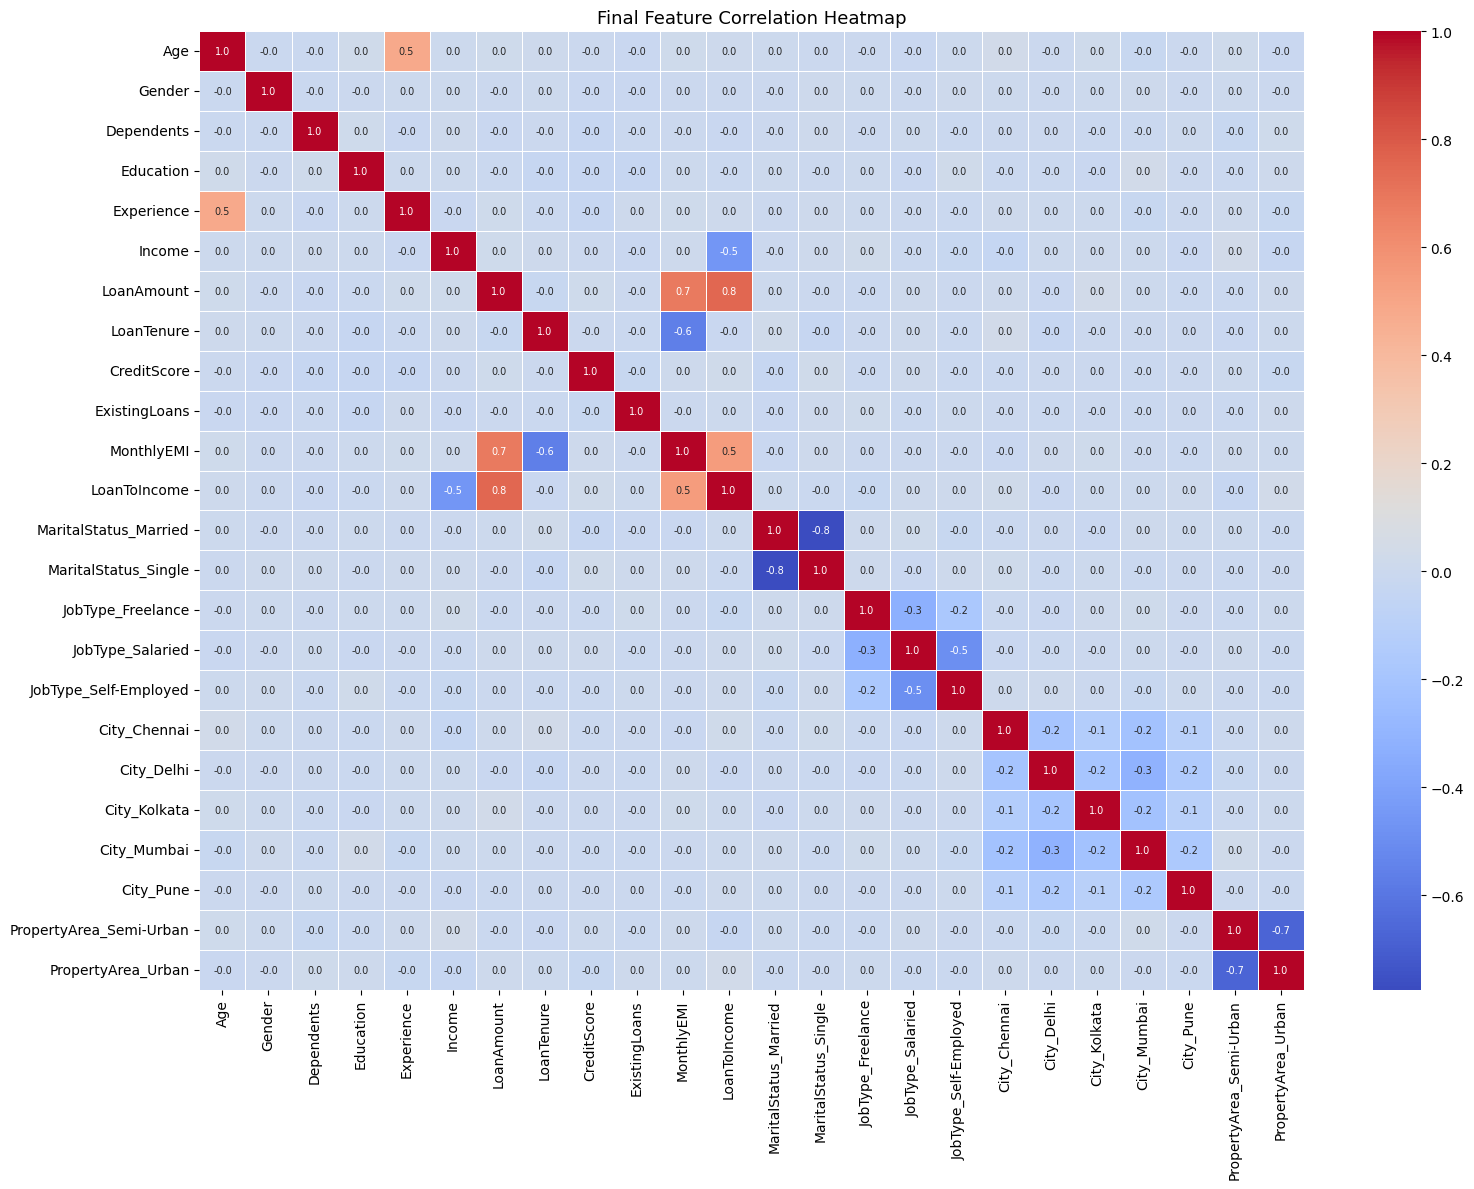

  Final shape    : (5000, 25)
  Target balance : {1: 3103, 0: 1897}

Saved → loan_approval_cleaned.csv
Train: (4000, 24) | Test: (1000, 24)


In [37]:
print(f"Shape before: {X.shape}")

selector = VarianceThreshold(threshold=0.01)
selector.fit(X)
low_var = X.columns[~selector.get_support()].tolist()
X = X.drop(columns=low_var) if low_var else X
print(f"Low-variance dropped: {low_var if low_var else 'None'}")

print(f"Shape after : {X.shape}")

# Correlation Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(X.corr(), annot=True, fmt=".1f", cmap="coolwarm",
            linewidths=0.5, annot_kws={"size": 7})
plt.title("Final Feature Correlation Heatmap", fontsize=13)
plt.tight_layout()
plt.show()

# Checklist
df_final = X.copy()
df_final[target] = y.values

print(f"  Final shape    : {df_final.shape}")
print(f"  Target balance : {y.value_counts().to_dict()}")

# Save
df_final.to_csv("loan_approval_cleaned.csv", index=False)
print("\nSaved → loan_approval_cleaned.csv")

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
